# VT solution comparison: single-source vs composite (double-source)

Compares the moment-tensor solutions obtained for the Campi Flegrei VT events with two
different source parametrizations:

- **single-source**: `catalogue_flegrei_MT_VT.pf` — one point source per event
- **composite / double-source**: `catalogue_flegrei_composite_VT_new_best.pf` — two point sources per event (joint VT + VLP inversion), best solution

Both catalogues are matched event-by-event by name, then compared with the Kagan angle and
the MT cosine angle, plus magnitude and depth.

In [17]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyrocko import model
import pyrocko.moment_tensor as pmt

In [18]:
workdir = '../'
catdir = os.path.join(workdir, 'CAT')
plotdir = os.path.join(workdir, 'PLOTS', 'VT_solution_comparison')
os.makedirs(plotdir, exist_ok=True)

file_single = os.path.join(catdir, 'catalogue_flegrei_MT_VT.pf')                     # single-source
file_composite = os.path.join(catdir, 'catalogue_flegrei_composite_VT_new_best.pf')  # composite / double-source

events_single = {ev.name: ev for ev in model.load_events(file_single)}
events_composite = {ev.name: ev for ev in model.load_events(file_composite)}

# events to leave out of the whole comparison below, by name (uncomment / add as needed)
excluded_events = [
    #'flegrei_2025_10_12_13_35_50',
    #'flegrei_2023_09_26_07_10_29'
]

common_names_all = sorted(set(events_single) & set(events_composite), key=lambda n: events_single[n].time)
common_names = [n for n in common_names_all if n not in excluded_events]

not_found = [n for n in excluded_events if n not in common_names_all]
if not_found:
    print(f'WARNING: excluded event name(s) not found in the matched catalogue: {not_found}')

print(f'matched 1:1 pairs: {len(common_names_all)} / {len(events_single)} single-source, {len(events_composite)} composite')
if len(common_names) != len(common_names_all):
    print(f'excluded by name: {[n for n in excluded_events if n in common_names_all]}')
print(f'events used below: {len(common_names)}')

matched 1:1 pairs: 19 / 19 single-source, 19 composite
events used below: 19


## Comparing the moment tensors: Kagan angle vs MT cosine angle

Both catalogues are purely deviatoric (checked below), but with substantial and variable CLVD
content (far from pure double-couple) — which matters for choosing a comparison metric:

- **Kagan angle** (`pyrocko.moment_tensor.kagan_angle`; Kagan, 1991; Tape & Tape, 2012) is
  computed only from the **eigenvectors** of the two tensors: the minimum rotation that aligns
  their T/B/P principal-axis frames, folded over the 4-fold symmetry that leaves a pure
  double-couple radiation pattern invariant. It is not restricted to pure double couples
  numerically — it runs on the eigenvectors of *any* moment tensor — but it completely
  **ignores the eigenvalues**, i.e. it is blind to how DC-like vs CLVD-like each solution is,
  and the symmetry it folds over is a strict invariance only for the DC case.
- **MT cosine angle** uses the full tensors instead: `cos(theta) = (M1:M2) / (|M1| |M2|)`
  (normalized Frobenius / double-dot product), `theta = arccos(cos(theta))`. It is sensitive to
  *both* orientation and the relative eigenvalue partition (DC/CLVD "shape"), so for these
  non-pure-DC sources it captures more of the actual disagreement between the two solutions —
  at the cost of not being a purely geometric/rotational measure.

In [19]:
def mt_cosine_similarity(mt1, mt2):
    """cosine of the angle between two moment tensors (normalized Frobenius / double-dot product)"""
    m1, m2 = mt1.m(), mt2.m()
    cos_sim = np.sum(m1 * m2) / (np.linalg.norm(m1) * np.linalg.norm(m2))
    return float(np.clip(cos_sim, -1.0, 1.0))


records = []
for n in common_names:
    mt1 = events_single[n].moment_tensor
    mt2 = events_composite[n].moment_tensor

    cos_sim = mt_cosine_similarity(mt1, mt2)
    records.append({
        'name': n,
        'time': events_single[n].time,
        'kagan_angle_deg': pmt.kagan_angle(mt1, mt2),
        'mt_cosine_similarity': cos_sim,
        'mt_cosine_angle_deg': np.degrees(np.arccos(cos_sim)),
    })

df = pd.DataFrame(records)
df.to_csv(os.path.join(plotdir, 'VT_solution_comparison_table.csv'), index=False)

iso_max = 100 * max(
    np.max(np.abs([events_single[n].moment_tensor.standard_decomposition()[0][1] for n in common_names])),
    np.max(np.abs([events_composite[n].moment_tensor.standard_decomposition()[0][1] for n in common_names])),
)
print(f'sanity check: max |ISO%| across both catalogues = {iso_max:.2e} % (both are purely deviatoric)')

df

sanity check: max |ISO%| across both catalogues = 1.28e-04 % (both are purely deviatoric)


,name,time,kagan_angle_deg,mt_cosine_similarity,mt_cosine_angle_deg
0,flegrei_2018_09_18_21_36_41,1.537307e+09,31.055332,0.980834,11.235576
1,flegrei_2023_06_11_06_44_25,1.686466e+09,35.104578,0.728983,43.198835
2,flegrei_2023_09_26_07_10_29,1.695712e+09,72.370546,-0.326553,109.059686
3,flegrei_2023_10_02_20_08_26,1.696277e+09,20.900676,0.933262,21.050916
4,flegrei_2024_04_27_03_44_56,1.714189e+09,16.004843,0.869689,29.577501
5,flegrei_2024_05_22_06_28_00,1.716359e+09,42.910366,0.539853,57.326384
6,flegrei_2024_06_08_01_52_04,1.717812e+09,60.589068,-0.082921,94.756472
7,flegrei_2024_06_18_01_58_24,1.718676e+09,36.048052,0.824222,34.490331
8,flegrei_2024_07_26_11_46_21,1.721994e+09,32.675627,0.539526,57.348592
9,flegrei_2024_08_30_19_23_15,1.725046e+09,50.803219,0.510512,59.302066


In [20]:
mean_kagan, std_kagan = np.mean(df['kagan_angle_deg']), np.std(df['kagan_angle_deg'])
mean_cos, std_cos = np.mean(df['mt_cosine_angle_deg']), np.std(df['mt_cosine_angle_deg'])
r_kc = np.corrcoef(df['kagan_angle_deg'], df['mt_cosine_angle_deg'])[0, 1]

print(f'Kagan angle:      mean = {mean_kagan:6.2f} deg +- {std_kagan:5.2f} deg (std)')
print(f'MT cosine angle:  mean = {mean_cos:6.2f} deg +- {std_cos:5.2f} deg (std)')
print(f'\ncorrelation (Pearson r) between the two metrics: {r_kc:.2f}')
print(f'MT cosine angle >= Kagan angle for {(df["mt_cosine_angle_deg"] >= df["kagan_angle_deg"]).sum()}/{len(df)} events')

Kagan angle:      mean =  43.92 deg +- 20.83 deg (std)
MT cosine angle:  mean =  55.41 deg +- 28.54 deg (std)

correlation (Pearson r) between the two metrics: 0.87
MT cosine angle >= Kagan angle for 16/19 events


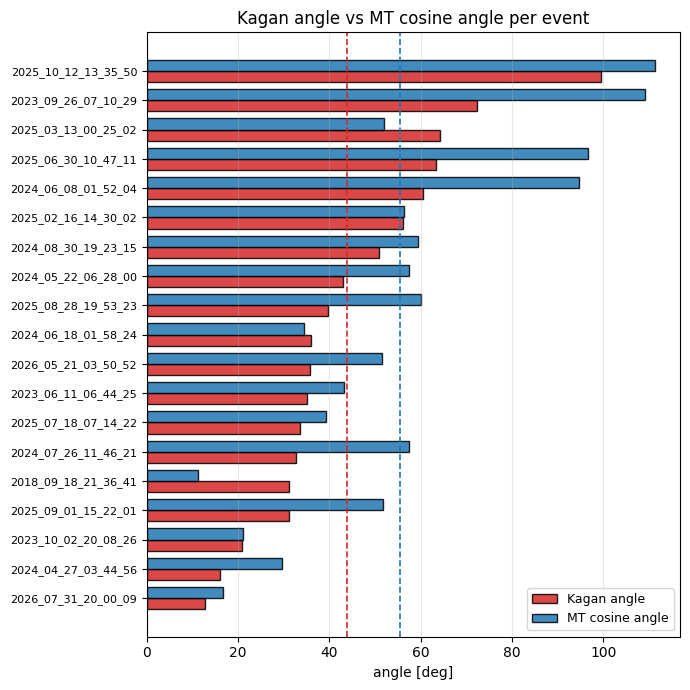

In [21]:
order = df.sort_values('kagan_angle_deg', ascending=True)
y = np.arange(len(order))
h = 0.38

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(y - h / 2, order['kagan_angle_deg'], h, color='tab:red', edgecolor='k', alpha=0.85, label='Kagan angle')
ax.barh(y + h / 2, order['mt_cosine_angle_deg'], h, color='tab:blue', edgecolor='k', alpha=0.85, label='MT cosine angle')
ax.axvline(mean_kagan, color='tab:red', ls='--', lw=1.2)
ax.axvline(mean_cos, color='tab:blue', ls='--', lw=1.2)
ax.set_yticks(y)
ax.set_yticklabels([n.replace('flegrei_', '') for n in order['name']], fontsize=8)
ax.set_xlabel('angle [deg]')
ax.set_title('Kagan angle vs MT cosine angle per event')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig(os.path.join(plotdir, 'kagan_vs_cosine_per_event.pdf'))
plt.show()

%DC single-source:    mean =  60.9 % +- 22.3 % (std)
%DC composite-source: mean =  61.6 % +- 24.1 % (std)


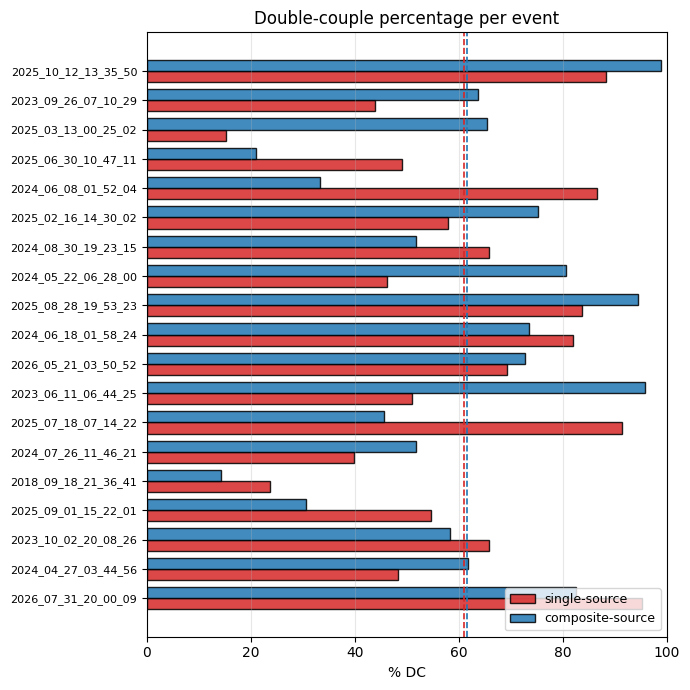

In [22]:
dc_single = np.array([events_single[n].moment_tensor.standard_decomposition()[1][1] * 100 for n in common_names])
dc_composite = np.array([events_composite[n].moment_tensor.standard_decomposition()[1][1] * 100 for n in common_names])

print(f'%DC single-source:    mean = {np.mean(dc_single):5.1f} % +- {np.std(dc_single):4.1f} % (std)')
print(f'%DC composite-source: mean = {np.mean(dc_composite):5.1f} % +- {np.std(dc_composite):4.1f} % (std)')

# same event order as the Kagan/cosine plot above, for easy cross-reference
order = df.sort_values('kagan_angle_deg', ascending=True)
dc_single_o = dc_single[order.index]
dc_composite_o = dc_composite[order.index]
y = np.arange(len(order))
h = 0.38

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(y - h / 2, dc_single_o, h, color='tab:red', edgecolor='k', alpha=0.85, label='single-source')
ax.barh(y + h / 2, dc_composite_o, h, color='tab:blue', edgecolor='k', alpha=0.85, label='composite-source')
ax.axvline(np.mean(dc_single), color='tab:red', ls='--', lw=1.2)
ax.axvline(np.mean(dc_composite), color='tab:blue', ls='--', lw=1.2)
ax.set_yticks(y)
ax.set_yticklabels([n.replace('flegrei_', '') for n in order['name']], fontsize=8)
ax.set_xlabel('% DC')
ax.set_xlim(0, 100)
ax.set_title('Double-couple percentage per event')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig(os.path.join(plotdir, 'dc_percent_per_event.pdf'))
plt.show()

## Magnitude and depth comparison

magnitude difference (single - composite): mean = -0.036, std = 0.095
RMS = 0.101, Pearson r = 0.985


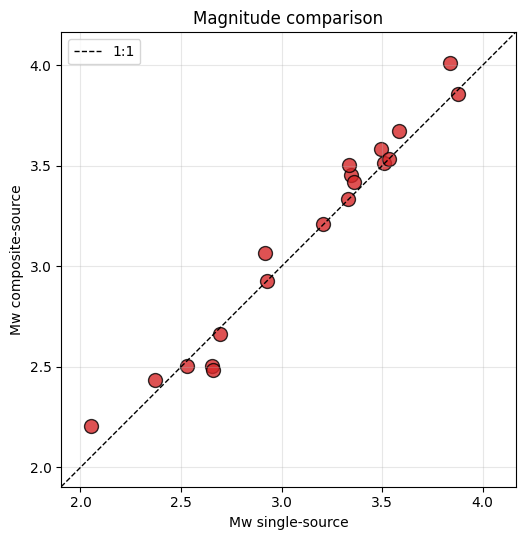

In [23]:
mag_single = np.array([events_single[n].magnitude for n in common_names])
mag_composite = np.array([events_composite[n].magnitude for n in common_names])
delta_mag = mag_single - mag_composite

print(f'magnitude difference (single - composite): mean = {np.mean(delta_mag):.3f}, std = {np.std(delta_mag):.3f}')
print(f'RMS = {np.sqrt(np.mean(delta_mag ** 2)):.3f}, Pearson r = {np.corrcoef(mag_single, mag_composite)[0, 1]:.3f}')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(mag_single, mag_composite, c='tab:red', s=100, edgecolors='k', alpha=0.8)
lims = [min(mag_single.min(), mag_composite.min()) - 0.15, max(mag_single.max(), mag_composite.max()) + 0.15]
ax.plot(lims, lims, 'k--', lw=1, label='1:1')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Mw single-source')
ax.set_ylabel('Mw composite-source')
ax.set_title('Magnitude comparison')
ax.legend()
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(os.path.join(plotdir, 'magnitude_comparison.pdf'))
plt.show()

depth difference (single - composite): mean = 0.126 km, std = 0.737 km
RMS = 0.747 km, Pearson r = 0.625


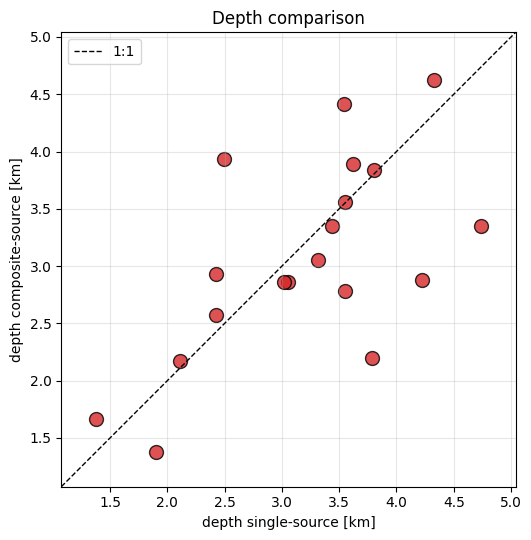

In [24]:
depth_single = np.array([events_single[n].depth for n in common_names]) / 1000.
depth_composite = np.array([events_composite[n].depth for n in common_names]) / 1000.
delta_depth = depth_single - depth_composite

print(f'depth difference (single - composite): mean = {np.mean(delta_depth):.3f} km, std = {np.std(delta_depth):.3f} km')
print(f'RMS = {np.sqrt(np.mean(delta_depth ** 2)):.3f} km, Pearson r = {np.corrcoef(depth_single, depth_composite)[0, 1]:.3f}')

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(depth_single, depth_composite, c='tab:red', s=100, edgecolors='k', alpha=0.8)
lims = [min(depth_single.min(), depth_composite.min()) - 0.3, max(depth_single.max(), depth_composite.max()) + 0.3]
ax.plot(lims, lims, 'k--', lw=1, label='1:1')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('depth single-source [km]')
ax.set_ylabel('depth composite-source [km]')
ax.set_title('Depth comparison')
ax.legend()
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(os.path.join(plotdir, 'depth_comparison.pdf'))
plt.show()